### Imports

In [1]:
import time

from collections import Counter
from itertools import combinations
from ucimlrepo import fetch_ucirepo 

import pandas as pd
import matplotlib.pyplot as plt

### Data Processing

In [2]:
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 

In [3]:
dataset = online_retail.data

In [4]:
df = dataset["original"]

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [6]:
len(df["InvoiceNo"].unique())

25900

In [7]:
len(df["Description"].unique())

4224

In [8]:
# The dataset is a list of transactions, where each transaction is a set of items


### DUMMY TRANSACTIONS
# transactions = [
#     {"milk", "tea", "yoghurt"},
#     {"milk", "oats"},
#     {"milk", "biscuits", "tea"},
#     {"muesli", "yoghurt"},
#     {"oats", "milk", "tea"},
#     {"muesli", "milk", "tea"}
# ]


### Complete Dataset
transactions = (
  df.groupby("InvoiceNo")["Description"]
  .apply(set)
  .tolist()
)

In [9]:
# Extract the set of all items

def get_items(transactions):
  items = set()
  for t in transactions:
    items.update(t)
  return items

In [10]:
items = get_items(transactions)

In [11]:
print(len(items))
print(items)

4224
{'PARTY PIZZA DISH BLUE POLKADOT', 'CAKE STAND LACE WHITE', 'Dotcomgiftshop Gift Voucher £40.00', 'PINK MONTE CARLO HANDBAG', 'ZINC BOX SIGN HOME', 'DOORMAT WELCOME SUNRISE', 'RETRO TIN ASHTRAY,REVOLUTIONARY', 'BAROQUE BUTTERFLY EARRINGS PINK', 'incorrectly credited C550456 see 47', 'NUMBER TILE COTTAGE GARDEN 7', 'SET OF 2 ROUND TINS CAMEMBERT ', 'SKULLS SQUARE TISSUE BOX', 'FRENCH STYLE STORAGE JAR JAM', '75 GREEN FAIRY CAKE CASES', 'CHILDS GARDEN FORK BLUE ', 'CREAM SLICE FLANNEL PINK SPOT ', 'WOODEN SKITTLES GARDEN SET', 'CANDLEHOLDER PINK HANGING HEART', 'TRAVEL CARD WALLET UNION JACK', 'BATHROOM HOOK', 'MURANO STYLE GLASS BRACELET RED', 'FLAMINGO LIGHTS', 'RECYCLED ACAPULCO MAT BLUE', 'WHITE SOAP RACK WITH 2 BOTTLES', 'RED POLKADOT PUDDING BOWL', 'RABBIT EASTER DECORATION', 'LARGE BLACK DIAMANTE HAIRSLIDE', 'damaged stock', 'DOILEY STORAGE TIN', '5 STRAND GLASS NECKLACE AMBER', 'SANDWICH BATH SPONGE', 'DOG BOWL VINTAGE CREAM', 'FINE SILVER NECKLACE W PASTEL FLOWE', 'CHARLIE 

In [12]:
def build_transactions(df, n_items):
    top_items = (
        df["Description"]
        .value_counts()
        .head(n_items)
        .index
    )

    df_small = df[df["Description"].isin(top_items)]

    transactions = (
        df_small.groupby("InvoiceNo")["Description"]
        .apply(set)
        .tolist()
    )

    return transactions

In [25]:
transactions = build_transactions(df, 5)

In [26]:
print(len(transactions))
print(transactions[:5])

7128
[{'WHITE HANGING HEART T-LIGHT HOLDER'}, {'WHITE HANGING HEART T-LIGHT HOLDER'}, {'WHITE HANGING HEART T-LIGHT HOLDER'}, {'LUNCH BAG RED RETROSPOT'}, {'JUMBO BAG RED RETROSPOT'}]


### Utils

In [18]:
def benchmark_algorithm(df, algorithm_fn, minsup, item_range):

    results = []

    for n_items in item_range:

        transactions = build_transactions(df, n_items)

        start = time.time()
        algorithm_fn(transactions, minsup)
        end = time.time()

        runtime = end - start

        results.append((n_items, runtime))

        print(f"Items={n_items} → {runtime:.3f}s")

    return results

## Fequent Itemset Mining

**What it does**: Solves the first step of **association rule mining** by finding all itemsets that appear frequently in the dataset

### Naive/Brute Force
**What it does:**
1. Collect all items in the dataset
2. Generate all possible itemsets (power set)
3. Compute support for each itemset
4. Keep only those above minsup

**Complexity:** $O(2^{|I|}\cdot|I|\cdot|T|)$

In [27]:
# Generate Power Set

def generate_itemsets(items):
  items = list(items)

  for k in range(1, len(items) + 1):
    for combo in combinations(items, k):
      yield set(combo)

In [28]:
itemsets = generate_itemsets(items)

In [29]:
itemsets

<generator object generate_itemsets at 0x0000018011A78D60>

Compute Support

The support counts how many transactions contain the itemset.

$support(X)=|\{t\in T: X\sube t\}$

In [30]:
def compute_support(itemset, transactions):
  count = 0

  for transaction in transactions:
    if itemset.issubset(transaction):
      count += 1
  
  return count

In [31]:
support_test = compute_support({"WHITE HANGING HEART T-LIGHT HOLDER"}, transactions)
support_test

2302

In [32]:
# Implement the Naive Mining Algorithm

def naive_frequent_itemsets(transactions, minsup):
  items = get_items(transactions)

  frequent_itemsets = []

  for itemset in generate_itemsets(items):

    support = compute_support(itemset, transactions)

    if support >= minsup:
      frequent_itemsets.append((itemset, support))

  return frequent_itemsets

In [33]:
start = time.time()

minsup = 1000

frequent_sets = sorted(naive_frequent_itemsets(transactions, minsup), key=lambda x: x[1], reverse=True)

end = time.time()

print("Execution time:", end-start)

print("Frequent sets:")
for itemset, support in frequent_sets:
  print(itemset, support)

Execution time: 0.05193161964416504
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706
{'LUNCH BAG RED RETROSPOT'} 1607


In [92]:
run_times_naive = []
for n_items in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
  top_items = (
    df["Description"]
    .value_counts()
    .head(n_items)
    .index
  )

  df_small = df[df["Description"].isin(top_items)]

  transactions = (
    df_small.groupby("InvoiceNo")["Description"]
    .apply(set)
    .tolist()
  )

  start = time.time()

  minsup = 1000

  frequent_sets = naive_frequent_itemsets(transactions, minsup)
  frequent_sets.sort(key=lambda x: x[1], reverse=True)

  end = time.time()

  run_times_naive.append((n_items, end-start))

  print(f"\n===== n_items = {n_items} =====")

  print("Execution time:", end-start)

  print(f"Frequent sets:")
  for itemset, support in frequent_sets:
    print(itemset, support)



===== n_items = 1 =====
Execution time: 0.001001119613647461
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302

===== n_items = 2 =====
Execution time: 0.007762908935546875
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169

===== n_items = 3 =====
Execution time: 0.0066640377044677734
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135

===== n_items = 4 =====
Execution time: 0.024355173110961914
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706

===== n_items = 5 =====
Execution time: 0.0456085205078125
Frequent sets:
{'WHITE HANGING HEART T-LIGHT HOLDER'} 2302
{'REGENCY CAKESTAND 3 TIER'} 2169
{'JUMBO BAG RED RETROSPOT'} 2135
{'PARTY BUNTING'} 1706
{'LUNCH BAG RED RETROSPOT'} 1607

===== n_items = 6 =====
Execution time: 0.08976173400878906
Frequent sets:
{'WHIT

In [93]:
run_times_naive

[(1, 0.001001119613647461),
 (2, 0.007762908935546875),
 (3, 0.0066640377044677734),
 (4, 0.024355173110961914),
 (5, 0.0456085205078125),
 (6, 0.08976173400878906),
 (7, 0.2067885398864746),
 (8, 0.3615748882293701),
 (9, 0.8324477672576904),
 (10, 1.8947069644927979),
 (11, 4.054913282394409),
 (12, 5.964810371398926),
 (13, 12.084396123886108),
 (14, 34.53339147567749),
 (15, 71.3512761592865)]

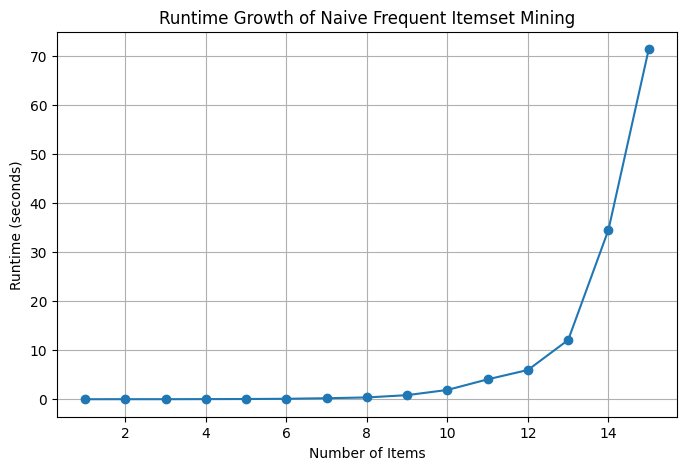

In [94]:
import matplotlib.pyplot as plt

num_items, run_times = zip(*run_times_naive)

plt.figure(figsize=(8,5))
plt.plot(num_items, run_times, marker="o")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Growth of Naive Frequent Itemset Mining")
plt.grid(True)

plt.show()

### Apriori

**Main idea:**  
Uses the **anti-monotonicity of support** to avoid exploring useless itemsets.

If an itemset is infrequent → all its supersets are also infrequent.

This allows the algorithm to **prune large portions of the search space** and avoid the exponential explosion of the naive approach.

**What it does:**

1. Find frequent 1-itemsets (scan dataset once)
2. Generate candidate k-itemsets from frequent (k-1)-itemsets
3. Prune candidates that contain any infrequent subset
4. Count support of remaining candidates (scan dataset)
5. Repeat level-wise until no new frequent itemsets are found

**Search strategy:**  
Level-wise Breadth-First Search in the subset lattice.

**Complexity (worst case):**

$$
O(2^{|I|} \cdot |T|)
$$

However, in practice the pruning step drastically reduces the number of candidates.

**Main limitations:**

- Requires multiple scans over the dataset  
- Must store all candidates of a level in memory  
- Performance degrades when:
  - minimum support is low  
  - dataset is dense  
  - transactions are large  

**Strengths:**

- Much faster than naive brute force  
- Conceptually simple  
- Good for sparse datasets with moderate support thresholds

**Intuition:**

Apriori sill has exponential worst-case complexity because:
- In dense datasets almost all subsets may be frequent
- Then pruning does not help
But in practice Apriori behaves closer to:
$$
O(k\cdot|T|\cdot C_k)
$$

Where:
- k = max itemset size
- Ck = number of candidates at level k

So runtime depends strongly on:
- `minsup`
- dataset density
- item distribution

In [95]:
def frequent_1_itemsets(transactions, minsup):
  counter = Counter()

  for t in transactions:
    counter.update(t)
  
  return {
    frozenset([item]): sup
    for item, sup in counter.items()
    if sup >= minsup
  }

In [96]:
def generate_candidates(prev_level):
  prev_sets = list(prev_level.keys())
  candidates = set()

  for i in range(len(prev_sets)):
    for j in range(i+1, len(prev_sets)):
      union = prev_sets[i] | prev_sets[j]

      if len(union) == len(prev_sets[i]) + 1:
        candidates.add(union)
  
  return candidates

In [97]:
def prune_candidates(candidates, prev_level):
  prev_sets = set(prev_level.keys())
  pruned = set()

  for c in candidates:
    all_subsets_frequent = True

    for item in c:
      subset = c - {item}
      if subset not in prev_sets:
        all_subsets_frequent = False
        break

    if all_subsets_frequent:
      pruned.add(c)
  
  return pruned

In [98]:
def count_support(candidates, transactions, minsup):
  counts = Counter()

  for t in transactions:
    for c in candidates:
      if c.issubset(t):
        counts[c] += 1
  
  return {
    c: sup
    for c, sup in counts.items()
    if sup >= minsup
  }

In [99]:
def apriori(transactions, minsup):

  L = []
  L1 = frequent_1_itemsets(transactions, minsup)
  L.append(L1)

  k = 1

  while L[k-1]:
    candidates = generate_candidates(L[k-1])
    candidates = prune_candidates(candidates, L[k-1])

    Lk = count_support(candidates, transactions, minsup)

    if not Lk:
      break

    L.append(Lk)
    k += 1
  
  return L

In [100]:
apriori(transactions, 1000)

[{frozenset({'WHITE HANGING HEART T-LIGHT HOLDER'}): 2302,
  frozenset({'ASSORTED COLOUR BIRD ORNAMENT'}): 1467,
  frozenset({'JAM MAKING SET WITH JARS'}): 1220,
  frozenset({'POSTAGE'}): 1250,
  frozenset({'JUMBO STORAGE BAG SUKI'}): 1201,
  frozenset({'PACK OF 72 RETROSPOT CAKE CASES'}): 1334,
  frozenset({'LUNCH BAG RED RETROSPOT'}): 1607,
  frozenset({'JUMBO BAG PINK POLKADOT'}): 1231,
  frozenset({'HEART OF WICKER SMALL'}): 1212,
  frozenset({'NATURAL SLATE HEART CHALKBOARD '}): 1266,
  frozenset({'JUMBO BAG RED RETROSPOT'}): 2135,
  frozenset({'LUNCH BAG  BLACK SKULL.'}): 1295,
  frozenset({'REGENCY CAKESTAND 3 TIER'}): 2169,
  frozenset({'PARTY BUNTING'}): 1706,
  frozenset({'SET OF 3 CAKE TINS PANTRY DESIGN '}): 1458}]

In [101]:
def apriori_wrapper(transactions, minsup):
    apriori(transactions, minsup)

In [102]:
run_times_apriori = benchmark_algorithm(
    df,
    apriori_wrapper,
    minsup=1000,
    item_range=range(1, 40)
)

Items=1 → 0.008s
Items=2 → 0.013s
Items=3 → 0.030s
Items=4 → 0.038s
Items=5 → 0.033s
Items=6 → 0.033s
Items=7 → 0.044s
Items=8 → 0.063s
Items=9 → 0.072s
Items=10 → 0.092s
Items=11 → 0.111s
Items=12 → 0.136s
Items=13 → 0.169s
Items=14 → 0.195s
Items=15 → 0.255s
Items=16 → 0.293s
Items=17 → 0.314s
Items=18 → 0.356s
Items=19 → 0.410s
Items=20 → 0.435s
Items=21 → 0.471s
Items=22 → 0.526s
Items=23 → 0.670s
Items=24 → 0.661s
Items=25 → 0.728s
Items=26 → 1.063s
Items=27 → 1.093s
Items=28 → 1.022s
Items=29 → 1.199s
Items=30 → 1.189s
Items=31 → 1.475s
Items=32 → 1.390s
Items=33 → 1.470s
Items=34 → 1.661s
Items=35 → 1.828s
Items=36 → 1.808s
Items=37 → 1.736s
Items=38 → 1.806s
Items=39 → 1.798s


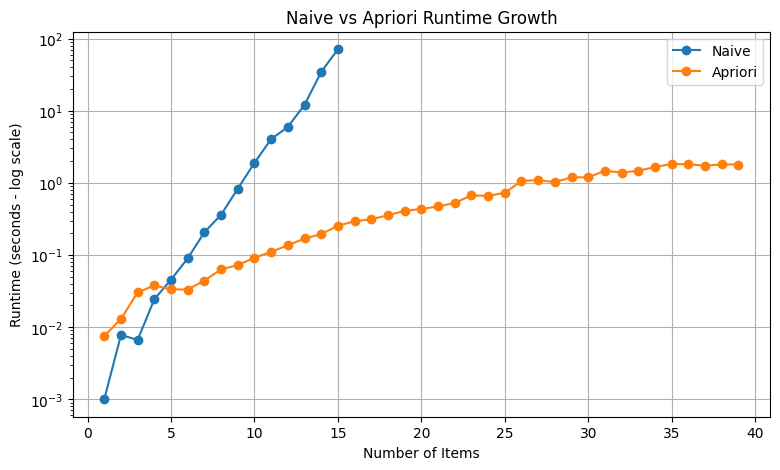

In [103]:
n1, t1 = zip(*run_times_naive)
n2, t2 = zip(*run_times_apriori)

plt.figure(figsize=(9,5))

plt.plot(n1, t1, marker="o", label="Naive")
plt.plot(n2, t2, marker="o", label="Apriori")

plt.yscale("log")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (seconds - log scale)")
plt.title("Naive vs Apriori Runtime Growth")

plt.legend()
plt.grid(True)
plt.show()

### Eclat

**Main idea:**  
Instead of scanning the dataset multiple times like Apriori,  
Eclat transforms the dataset into a **vertical representation**.

Each item is associated with the set of transaction IDs (tidset) where it appears.

The support of larger itemsets is computed by **intersecting tidsets**:

support(X ∪ Y) = | tidset(X) ∩ tidset(Y) |

This avoids repeated dataset scans and allows efficient depth-first exploration.

**What it does:**

1. Convert dataset to vertical format (item → tidset)
2. Start with frequent single items
3. Recursively intersect tidsets to build larger itemsets
4. Use Depth-First Search in the subset lattice
5. Stop expanding when support < minsup

**Search strategy:**  
Depth-First Search with vertical support counting.

**Complexity (worst case):**

$$
O(2^{|I|})
$$

But practical runtime depends on:

- size of tidsets  
- cost of intersections  
- dataset sparsity  
- minsup threshold  

**Strengths:**

- Avoids multiple dataset scans  
- Very fast on sparse datasets  
- Natural recursive search  
- Efficient support computation via set intersection  

**Limitations:**

- Tidsets may become large in dense datasets  
- Memory usage can be high  
- Performance depends on intersection cost  

**Key intuition:**

Apriori reduces candidate generation.  
Eclat reduces **support computation cost**.

In [104]:
transactions[:1]

[{'WHITE HANGING HEART T-LIGHT HOLDER'}]

In [105]:
# Build vertical format

def build_vertical(transactions):
  vertical = {}

  for tid, t in enumerate(transactions):
    for item in t:
      vertical.setdefault(item, set()).add(tid)
      
  return vertical

In [106]:
build_vertical(transactions)

{'WHITE HANGING HEART T-LIGHT HOLDER': {0,
  4,
  5,
  11,
  13,
  15,
  16,
  19,
  8214,
  29,
  30,
  8233,
  42,
  43,
  8234,
  8238,
  48,
  49,
  54,
  8246,
  56,
  57,
  58,
  59,
  8252,
  61,
  62,
  63,
  8256,
  68,
  69,
  8270,
  79,
  80,
  8274,
  87,
  88,
  89,
  8282,
  91,
  8283,
  99,
  100,
  8291,
  102,
  8298,
  108,
  109,
  110,
  8303,
  118,
  8310,
  120,
  8311,
  123,
  127,
  8321,
  8322,
  140,
  142,
  145,
  148,
  8346,
  156,
  158,
  160,
  162,
  163,
  167,
  168,
  8362,
  8365,
  174,
  177,
  8371,
  193,
  200,
  8393,
  202,
  204,
  205,
  206,
  8397,
  8399,
  213,
  215,
  216,
  8410,
  8414,
  8416,
  227,
  230,
  232,
  8424,
  8425,
  235,
  239,
  8431,
  8432,
  242,
  8434,
  244,
  8435,
  247,
  8440,
  249,
  250,
  8448,
  259,
  8452,
  261,
  8454,
  8459,
  268,
  269,
  270,
  271,
  8463,
  273,
  277,
  8470,
  279,
  280,
  8477,
  287,
  289,
  290,
  291,
  8482,
  8483,
  8485,
  295,
  8492,
  304,
  305,
  308

In [107]:
def eclat(prefix, items, minsup, frequent):

  while items:
    item, tidset = items.pop()

    new_prefix = prefix | {item}
    support = len(tidset)

    if support >= minsup:
      frequent.append((new_prefix, support))

      new_items = []

      for other_item, other_tidset in items:
        inter = tidset & other_tidset
        if len(inter) >= minsup:
          new_items.append((other_item, inter))
      
      if new_items:
        eclat(new_prefix, new_items, minsup, frequent)

def run_eclat(transactions, minsup):

  vertical = build_vertical(transactions)

  items = [(item, tidset) for item, tidset in vertical.items()]

  frequent = []

  eclat(set(), items, minsup, frequent)

  return frequent

In [108]:
def eclat_wrapper(transactions, minsup):
    run_eclat(transactions, minsup)

In [109]:
run_times_eclat = benchmark_algorithm(
    df,
    eclat_wrapper,
    minsup=1000,
    item_range=range(1,40)
)

Items=1 → 0.001s
Items=2 → 0.003s
Items=3 → 0.004s
Items=4 → 0.005s
Items=5 → 0.009s
Items=6 → 0.010s
Items=7 → 0.020s
Items=8 → 0.012s
Items=9 → 0.006s
Items=10 → 0.027s
Items=11 → 0.015s
Items=12 → 0.020s
Items=13 → 0.020s
Items=14 → 0.022s
Items=15 → 0.028s
Items=16 → 0.030s
Items=17 → 0.035s
Items=18 → 0.031s
Items=19 → 0.025s
Items=20 → 0.035s
Items=21 → 0.037s
Items=22 → 0.045s
Items=23 → 0.045s
Items=24 → 0.048s
Items=25 → 0.047s
Items=26 → 0.050s
Items=27 → 0.056s
Items=28 → 0.057s
Items=29 → 0.050s
Items=30 → 0.060s
Items=31 → 0.066s
Items=32 → 0.068s
Items=33 → 0.072s
Items=34 → 0.085s
Items=35 → 0.083s
Items=36 → 0.089s
Items=37 → 0.080s
Items=38 → 0.080s
Items=39 → 0.096s


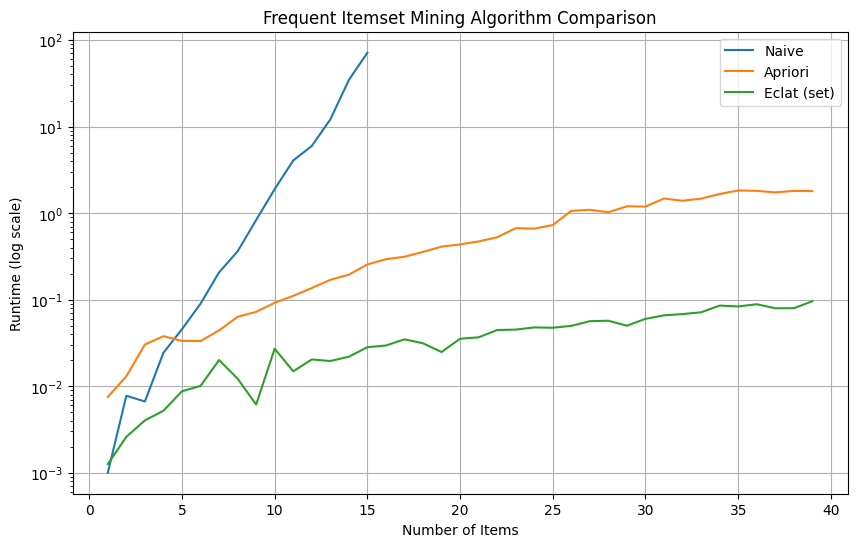

In [110]:
n3, t3 = zip(*run_times_eclat)

plt.figure(figsize=(10,6))

plt.plot(n1, t1, label="Naive")
plt.plot(n2, t2, label="Apriori")
plt.plot(n3, t3, label="Eclat (set)")

plt.yscale("log")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (log scale)")
plt.title("Frequent Itemset Mining Algorithm Comparison")

plt.legend()
plt.grid(True)
plt.show()

#### Diffsets e dEclat

Forma de melhorar a eficiência de memória em relação ao Eclat original

No Eclat:
$$
support(X) = |tidset(X)|
$$

No dEclat:
$$
support(PX) = support(P) - |diffset(PX)|
$$

No dEclat para gerar o diffset do próximo nível:
$$
d(PXY) = d(PY) - d(PX)
$$


Eclat $\rarr$ rápido em datasets **esparsos**

dEclat $\rarr$ melhor em datasets **densos**


#### dEclat (Diffset Eclat)

dEclat is an optimization of the Eclat algorithm that stores **diffsets instead of tidsets**.

A diffset represents the transactions where a prefix occurs but the extended itemset does not.

Support is computed as:

support(PX) = support(P) − |diffset(PX)|

This reduces memory usage and speeds up support computation in **dense datasets**, where tidsets tend to be large.

**Strengths:**

- Smaller memory footprint in dense datasets  
- Faster intersection-like operations  
- Efficient recursive search  

**Limitations:**

- Slightly more complex support computation  
- May be less advantageous in sparse datasets  

**Complexity (worst case):**

$$
O(2^{|I|})
$$

But practical performance depends heavily on dataset density and support threshold.

In [111]:
def build_vertical_tidsets(transactions):
  vertical = {}

  for tid, t in enumerate(transactions):
    for item in t:
      vertical.setdefault(item, set()).add(tid)
  
  return vertical

In [112]:
def initial_diffsets(transactions):

  T = set(range(len(transactions)))
  vertical = build_vertical_tidsets(transactions)

  P = []

  for item, tidset in vertical.items():
    diff = T - tidset
    support = len(tidset)

    P.append((frozenset([item]), diff, support))

  return P

In [113]:
def declat(prefix, items, minsup, frequent):
  while items:
    X, diffX, supX = items.pop()

    new_prefix = prefix | X

    if supX >= minsup:
      frequent.append((new_prefix, supX))

      new_items = []

      for Y, diffY, supY in items:
        diffXY = diffY - diffX

        supXY = supX - len(diffXY)

        if supXY >= minsup:
          new_items.append((Y, diffXY, supXY))
      
      if new_items:
        declat(new_prefix, new_items, minsup, frequent)

In [114]:
def run_declat(transactions, minsup):
  items = initial_diffsets(transactions)

  frequent = []

  declat(frozenset(), items, minsup, frequent)

  return frequent

In [115]:
def declat_wrapper(transactions, minsup):
  run_declat(transactions, minsup)

In [116]:
run_times_declat = benchmark_algorithm(
  df,
  declat_wrapper,
  minsup=1000,
  item_range=range(1,40)
)

Items=1 → 0.000s
Items=2 → 0.005s
Items=3 → 0.011s
Items=4 → 0.008s
Items=5 → 0.015s
Items=6 → 0.017s
Items=7 → 0.021s
Items=8 → 0.035s
Items=9 → 0.036s
Items=10 → 0.042s
Items=11 → 0.050s
Items=12 → 0.060s
Items=13 → 0.061s
Items=14 → 0.067s
Items=15 → 0.074s
Items=16 → 0.086s
Items=17 → 0.099s
Items=18 → 0.106s
Items=19 → 0.110s
Items=20 → 0.153s
Items=21 → 0.130s
Items=22 → 0.142s
Items=23 → 0.148s
Items=24 → 0.163s
Items=25 → 0.209s
Items=26 → 0.217s
Items=27 → 0.219s
Items=28 → 0.226s
Items=29 → 0.241s
Items=30 → 0.252s
Items=31 → 0.284s
Items=32 → 0.282s
Items=33 → 0.293s
Items=34 → 0.337s
Items=35 → 0.333s
Items=36 → 0.423s
Items=37 → 0.383s
Items=38 → 0.403s
Items=39 → 0.371s


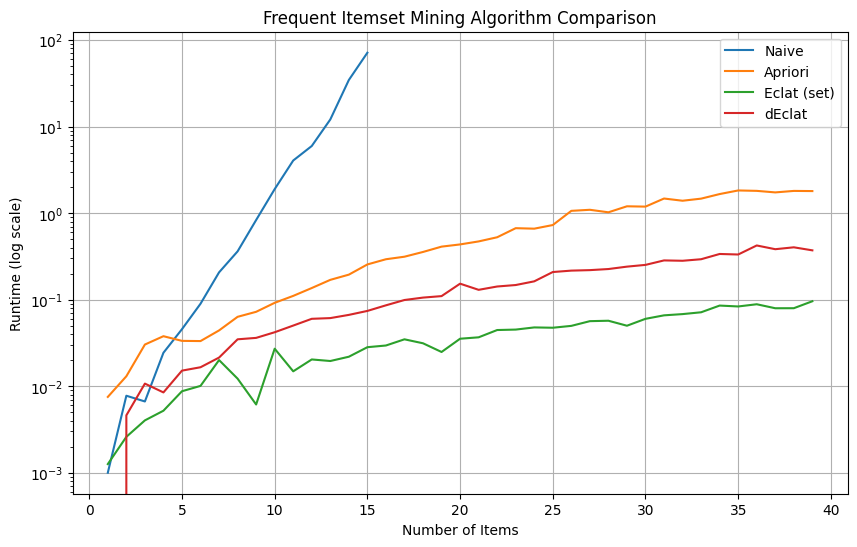

In [117]:
n4, t4 = zip(*run_times_declat)

plt.figure(figsize=(10,6))

plt.plot(n1, t1, label="Naive")
plt.plot(n2, t2, label="Apriori")
plt.plot(n3, t3, label="Eclat (set)")
plt.plot(n4, t4, label="dEclat")

plt.yscale("log")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (log scale)")
plt.title("Frequent Itemset Mining Algorithm Comparison")

plt.legend()
plt.grid(True)
plt.show()

### FP-Tree

In [118]:
def item_frequencies(transactions):
  counter = Counter()
  for t in transactions:
    counter.update(t)
  return counter

In [119]:
def filter_frequent(counter, minsup):
  return {item: sup for item, sup in counter.items() if sup >= minsup}

In [120]:
class FPNode:
  def __init__(self, item, parent):
    self.item = item
    self.count = 1
    self.parent = parent
    self.children = {}
    self.link = None
  
  def increment(self):
    self.count += 1

In [121]:
def build_header_table(freq_items):
  header = {}
  for item, sup in freq_items.items():
    header[item] = [sup, None]
  return header

In [122]:
def insert_tree(items, node, header):
  if not items:
    return
  
  first = items[0]

  if first in node.children:
    node.children[first].increment()
  else:
    new_node = FPNode(first, node)
    node.children[first] = new_node

    if header[first][1] is None:
      header[first][1] = new_node
    else:
      current = header[first][1]
      while current.link:
        current = current.link
      current.link = new_node

  insert_tree(items[1:], node.children[first], header)
      

In [123]:
def build_fptree(transactions, minsup):
  freq = item_frequencies(transactions)
  freq = filter_frequent(freq, minsup)

  if len(freq) == 0:
    return None, None
  
  header = build_header_table(freq)

  root = FPNode(None, None)

  for t in transactions:

    filtered = [i for i in t if i in freq]

    sorted_items = sorted(
      filtered,
      key=lambda x: freq[x],
      reverse=True
    )

    insert_tree(sorted_items, root, header)

  return root, header

In [124]:
def ascend_tree(node):
  path = []
  while node.parent and node.parent.item is not None:
    node = node.parent
    path.append(node.item)
  return path

In [125]:
def conditional_pattern_base(item, header):

  base = []

  node = header[item][1]

  while node:
    path = ascend_tree(node)
    if path:
      base.append((path, node.count))
    node = node.link

  return base

In [126]:
def mine_tree(header, minsup, prefix, frequent):
  items = sorted(header.items(), key=lambda x: x[1][0])

  for item, (support, node) in items:
    new_pattern = prefix | {item}
    frequent.append((new_pattern, support))

    cond_base = conditional_pattern_base(item, header)

    cond_transactions = []
    for path, count in cond_base:
      cond_transactions.extend([path] * count)

    cond_tree, cond_header = build_fptree(cond_transactions, minsup)

    if cond_header:
      mine_tree(cond_header, minsup, new_pattern, frequent)

In [127]:
def fpgrowth(transactions, minsup):
  tree, header = build_fptree(transactions, minsup)

  frequent = []

  if header:
    mine_tree(header, minsup, set(), frequent)
  
  return frequent

In [128]:
fpgrowth(transactions, 1000)

[({'JUMBO STORAGE BAG SUKI'}, 1201),
 ({'HEART OF WICKER SMALL'}, 1212),
 ({'JAM MAKING SET WITH JARS'}, 1220),
 ({'JUMBO BAG PINK POLKADOT'}, 1231),
 ({'POSTAGE'}, 1250),
 ({'NATURAL SLATE HEART CHALKBOARD '}, 1266),
 ({'LUNCH BAG  BLACK SKULL.'}, 1295),
 ({'PACK OF 72 RETROSPOT CAKE CASES'}, 1334),
 ({'SET OF 3 CAKE TINS PANTRY DESIGN '}, 1458),
 ({'ASSORTED COLOUR BIRD ORNAMENT'}, 1467),
 ({'LUNCH BAG RED RETROSPOT'}, 1607),
 ({'PARTY BUNTING'}, 1706),
 ({'JUMBO BAG RED RETROSPOT'}, 2135),
 ({'REGENCY CAKESTAND 3 TIER'}, 2169),
 ({'WHITE HANGING HEART T-LIGHT HOLDER'}, 2302)]

In [129]:
def fpgrowth_wrapper(transactions, minsup):
  fpgrowth(transactions, minsup)

In [130]:
run_times_fpgrowth = benchmark_algorithm(
  df,
  fpgrowth_wrapper,
  minsup=1000,
  item_range=range(1, 40)
)

Items=1 → 0.021s
Items=2 → 0.045s
Items=3 → 0.050s
Items=4 → 0.052s
Items=5 → 0.062s
Items=6 → 0.070s
Items=7 → 0.068s
Items=8 → 0.086s
Items=9 → 0.084s
Items=10 → 0.146s
Items=11 → 0.122s
Items=12 → 0.100s
Items=13 → 0.135s
Items=14 → 0.137s
Items=15 → 0.155s
Items=16 → 0.190s
Items=17 → 0.190s
Items=18 → 0.259s
Items=19 → 0.289s
Items=20 → 0.330s
Items=21 → 0.357s
Items=22 → 0.507s
Items=23 → 1.132s
Items=24 → 1.061s
Items=25 → 0.995s
Items=26 → 0.900s
Items=27 → 0.941s
Items=28 → 1.652s
Items=29 → 0.843s
Items=30 → 1.067s
Items=31 → 1.718s
Items=32 → 1.476s
Items=33 → 2.074s
Items=34 → 1.488s
Items=35 → 1.794s
Items=36 → 1.385s
Items=37 → 1.418s
Items=38 → 1.758s
Items=39 → 1.852s


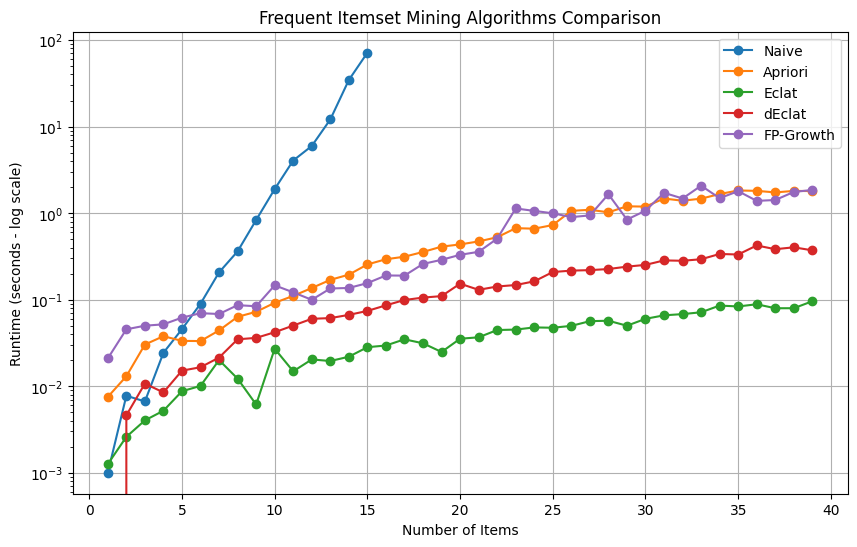

In [131]:
n5, t5 = zip(*run_times_fpgrowth)

plt.figure(figsize=(10,6))

plt.plot(n1, t1, marker="o", label="Naive")
plt.plot(n2, t2, marker="o", label="Apriori")
plt.plot(n3, t3, marker="o", label="Eclat")
plt.plot(n4, t4, marker="o", label="dEclat")
plt.plot(n5, t5, marker="o", label="FP-Growth")

plt.yscale("log")

plt.xlabel("Number of Items")
plt.ylabel("Runtime (seconds - log scale)")
plt.title("Frequent Itemset Mining Algorithms Comparison")

plt.legend()
plt.grid(True)

plt.show()